<a href="https://colab.research.google.com/github/dldklv/NN-DL/blob/main/third%20task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- 1. REAL DATASETNING DASTLABKI KO'RINISHI (Titanic) ---
    Jinsi  Yosh Shahar  Daromad   Holati
0    male  22.0      S   7.2500    kasal
1  female  38.0      C  71.2833  sog‘lom
2  female  26.0      S   7.9250  sog‘lom
3  female  35.0      S  53.1000  sog‘lom
4    male  35.0      S   8.0500    kasal
5    male   NaN      Q   8.4583    kasal
6    male  54.0      S  51.8625    kasal
7    male   2.0      S  21.0750    kasal
8  female  27.0      S  11.1333  sog‘lom
9  female  14.0      C  30.0708  sog‘lom


--- 2.1 Jinsi va Holati (0 / 1) ---
BEFORE:
     Jinsi   Holati
0    male    kasal
1  female  sog‘lom
2  female  sog‘lom
AFTER:
    Jinsi  Holati
0      1       1
1      0       0
2      0       0


--- 2.2 Bo'sh Yoshni Median (28.0) Bilan To'ldirish ---
BEFORE (NaN bor top 10):
 [22. 38. 26. 35. 35. nan 54.  2. 27. 14.]
AFTER (Median to'ldirildi):
 [22. 38. 26. 35. 35. 28. 54.  2. 27. 14.]


--- 2.3 OneHotEncoder Qo'llash (Shahar Ustuni) ---
BEFORE:
   Shahar
0      S
1      C
2    

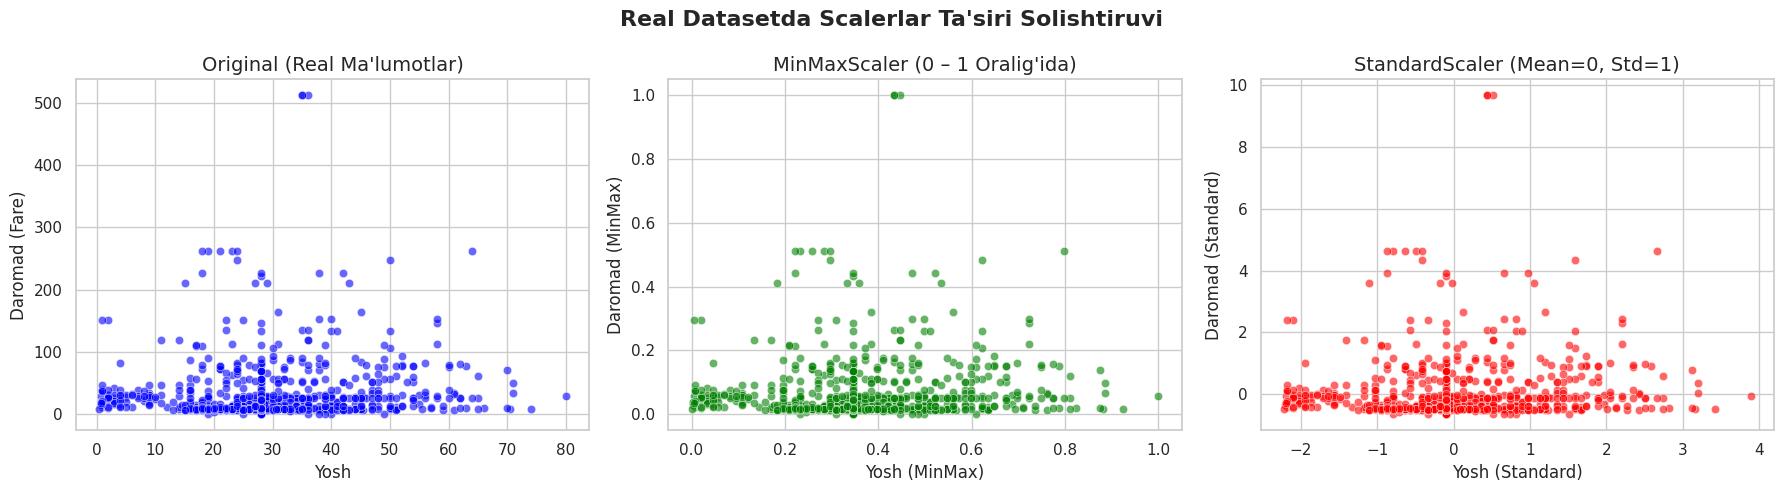

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder

sns.set_theme(style="whitegrid")

# ==========================================
# 1. HAQIQIY DATASETNI YUKLASH (Titanic Dataset)
# ==========================================
# Seaborn kutubxonasidan real ma'lumotlar to'plamini yuklaymiz
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
raw_df = pd.read_csv(url)

# Kerakli ustunlarni ajratib olamiz va uzbekcha nomlaymiz
# Survived -> Holati (0: vafot etgan/kasal, 1: tirik/sog'lom deb qaraladi)
# Sex -> Jinsi ('female', 'male')
# Age -> Yosh (ichida bo'sh qiymat NaN bor)
# Embarked -> Shahar ('C', 'Q', 'S')
# Fare -> Daromad/Chipta narxi
df = raw_df[['Sex', 'Age', 'Embarked', 'Fare', 'Survived']].copy()
df.columns = ['Jinsi', 'Yosh', 'Shahar', 'Daromad', 'Holati']

# Holatini shartga moslab o'zgartiramiz: tirik -> sog'lom, vafot etgan -> kasal
df['Holati'] = df['Holati'].map({1: 'sog‘lom', 0: 'kasal'})

print("--- 1. REAL DATASETNING DASTLABKI KO'RINISHI (Titanic) ---")
print(df.head(10))
print("\n" + "="*60 + "\n")


# ==========================================
# 2. QADAM-BA-QADAM QAYTA ISHLASH (BEFORE/AFTER)
# ==========================================

# 2.1 Jinsi: ayol/erkak -> 0/1 | Holati: sog'lom/kasal -> 0/1
df_step1 = df.copy()
df_step1['Jinsi'] = df_step1['Jinsi'].map({'female': 0, 'male': 1})
df_step1['Holati'] = df_step1['Holati'].map({'sog‘lom': 0, 'kasal': 1})

print("--- 2.1 Jinsi va Holati (0 / 1) ---")
print("BEFORE:\n", df[['Jinsi', 'Holati']].head(3))
print("AFTER:\n", df_step1[['Jinsi', 'Holati']].head(3))
print("\n" + "="*60 + "\n")


# 2.2 Bo'sh Yoshni median bilan to'ldirish
df_step2 = df_step1.copy()
yosh_median = df_step2['Yosh'].median()
df_step2['Yosh'] = df_step2['Yosh'].fillna(yosh_median)

print(f"--- 2.2 Bo'sh Yoshni Median ({yosh_median:.1f}) Bilan To'ldirish ---")
print("BEFORE (NaN bor top 10):\n", df_step1['Yosh'].head(10).values)
print("AFTER (Median to'ldirildi):\n", df_step2['Yosh'].head(10).values)
print("\n" + "="*60 + "\n")


# 2.3 OneHotEncoder bilan Shaharlarni alohida ustunlarga ajratish
df_step3 = df_step2.copy()
# Shahar ustunidagi bo'sh joylarni eng ko'p uchragan shahar bilan to'ldiramiz
df_step3['Shahar'] = df_step3['Shahar'].fillna(df_step3['Shahar'].mode()[0])

ohe = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
shahar_encoded = ohe.fit_transform(df_step3[['Shahar']])

df_step3 = pd.concat([df_step3.drop(columns=['Shahar']), shahar_encoded], axis=1)

print("--- 2.3 OneHotEncoder Qo'llash (Shahar Ustuni) ---")
print("BEFORE:\n", df_step2[['Shahar']].head(3))
print("AFTER (One-Hot Encoded):\n", shahar_encoded.head(3))
print("\n" + "="*60 + "\n")


# 2.4 MinMaxScaler va StandardScaler qo'llash
df_final = df_step3.copy()

min_max_scaler = MinMaxScaler()
standard_scaler = StandardScaler()

# MinMaxScaler (0-1 oralig'i)
df_final[['Yosh_MinMax', 'Daromad_MinMax']] = min_max_scaler.fit_transform(df_final[['Yosh', 'Daromad']])

# StandardScaler (Mean=0, Std=1)
df_final[['Yosh_Standard', 'Daromad_Standard']] = standard_scaler.fit_transform(df_final[['Yosh', 'Daromad']])

print("--- 2.4 Yakuniy Birlashtirilgan Dataset ---")
print(df_final.head())
print("\n" + "="*60 + "\n")


# ==========================================
# 3. STATISTIK KO'RSATKICHLARNI HISOBLASH
# ==========================================

def calculate_stats(series):
    q25, q75 = np.percentile(series.dropna(), [25, 75])
    iqr = q75 - q25
    mode_val = series.mode()[0] if not series.mode().empty else np.nan

    return {
        'Sum': series.sum(),
        'Min': series.min(),
        'Max': series.max(),
        'Mean': series.mean(),
        'Median': series.median(),
        'Mode': mode_val,
        'Variance': series.var(),
        'Std': series.std(),
        'Percentile_25': q25,
        'Percentile_75': q75,
        'IQR': iqr
    }

print("--- 3. REAL 'Yosh' USTUNI STATISTIKASI ---")
for stat_name, val in calculate_stats(df_final['Yosh']).items():
    print(f"{stat_name:15s}: {val:.2f}")

print("\n--- REAL 'Daromad' (Fare) USTUNI STATISTIKASI ---")
for stat_name, val in calculate_stats(df_final['Daromad']).items():
    print(f"{stat_name:15s}: {val:.2f}")

print("\n" + "="*60 + "\n")


# ==========================================
# 4. SCALERLARNI GRAFIKDA KO'RISH
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original Ma'lumotlar
sns.scatterplot(data=df_final, x='Yosh', y='Daromad', ax=axes[0], color='blue', alpha=0.6)
axes[0].set_title("Original (Real Ma'lumotlar)", fontsize=14)
axes[0].set_xlabel("Yosh")
axes[0].set_ylabel("Daromad (Fare)")

# MinMaxScaler
sns.scatterplot(data=df_final, x='Yosh_MinMax', y='Daromad_MinMax', ax=axes[1], color='green', alpha=0.6)
axes[1].set_title("MinMaxScaler (0 – 1 Oralig'ida)", fontsize=14)
axes[1].set_xlabel("Yosh (MinMax)")
axes[1].set_ylabel("Daromad (MinMax)")

# StandardScaler
sns.scatterplot(data=df_final, x='Yosh_Standard', y='Daromad_Standard', ax=axes[2], color='red', alpha=0.6)
axes[2].set_title("StandardScaler (Mean=0, Std=1)", fontsize=14)
axes[2].set_xlabel("Yosh (Standard)")
axes[2].set_ylabel("Daromad (Standard)")

plt.suptitle("Real Datasetda Scalerlar Ta'siri Solishtiruvi", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()